### Importing Necessary Libraries

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split , StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer 
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, roc_auc_score


### Load the Dataset

In [8]:
titanic_df = pd.read_csv("../data/train.csv")
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Step 1: Basic Data Checks

In [9]:
def basic_checks(data):
    print("-"*35, "Duplicates","-"*35)
    print(data.duplicated().sum())
    print("-"*35, "Shape", "-"*35)
    print(data.shape)
    print("-"*35, "Missing Values", "-"*35)
    print(data.isna().sum())
    print("-"*35, "Data Types", "-"*35)
    print(data.dtypes)
    print("-"*35, "Summary Statistics (Numerical)", "-"*35)
    print(display(data.describe().T))
    print("-"*35, "Summary Statistics Categorical Data", "-"*35)
    print(display(data.describe(include = ["str","object"]).T))


In [10]:
basic_checks(titanic_df)

----------------------------------- Duplicates -----------------------------------
0
----------------------------------- Shape -----------------------------------
(891, 12)
----------------------------------- Missing Values -----------------------------------
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
----------------------------------- Data Types -----------------------------------
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object
----------------------------------- Summary Statistics (Numerical) -----------------------------------


,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


None
----------------------------------- Summary Statistics Categorical Data -----------------------------------


,count,unique,top,freq
Name,891,891,"Braund, Mr. Owen Harris",1
Sex,891,2,male,577
Ticket,891,681,347082,7
Cabin,204,147,G6,4
Embarked,889,3,S,644


None


#### Checking Unique Entries in Categorical Columns

In [13]:
categorical_cols = ["Pclass", "Sex", "Embarked"]

for col in categorical_cols:
    print("-"*35, col,"-"*35)
    print(titanic_df[col].unique())
    


----------------------------------- Pclass -----------------------------------
[3 1 2]
----------------------------------- Sex -----------------------------------
<StringArray>
['male', 'female']
Length: 2, dtype: str
----------------------------------- Embarked -----------------------------------
<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str


__Percentage of missing values__

In [14]:
(titanic_df.isnull().sum() / len(titanic_df)) * 100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

__Dropping the Cabin Column__

In [16]:
titanic_df = titanic_df.drop(columns =["Cabin"])

In [17]:
titanic_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='str')

### Step 2: Distribution of the Target Column

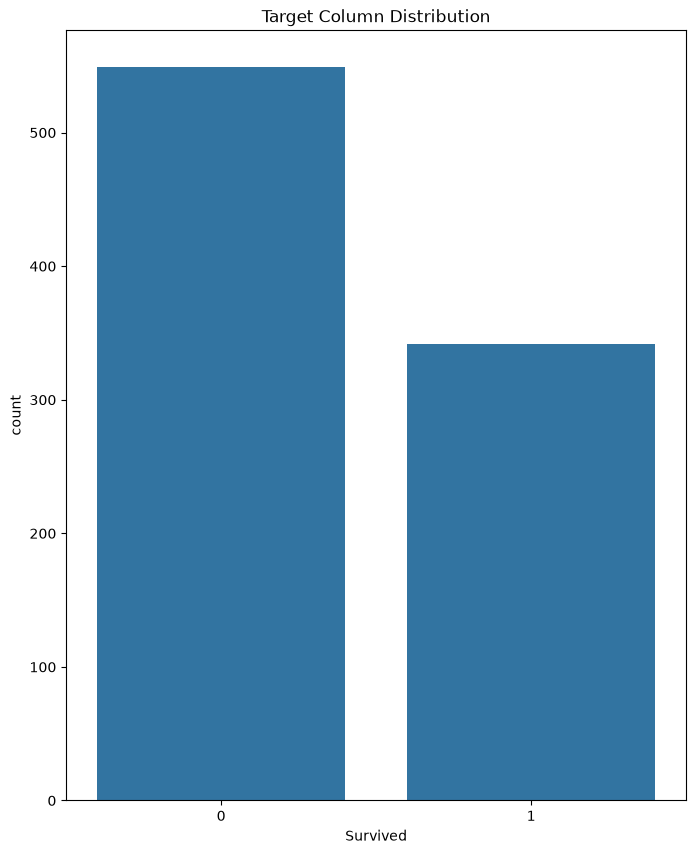

In [23]:
plt.figure(figsize=(8,10))

sns.countplot(titanic_df, x = "Survived")
plt.xlabel("Survived")
plt.title("Target Column Distribution")

plt.show()


### Step 3: Splitting the target and the features

In [21]:
X = titanic_df.drop(columns = ["PassengerId", "Name", "Ticket", "Survived"])
y = titanic_df["Survived"]

In [22]:
X.columns

Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked'], dtype='str')

__Separating Numerical and Categorical Columns__

In [24]:
numerical_columns = ["Age", "SibSp", "Parch", "Fare"]
categorical_columns = ["Pclass", "Sex", "Embarked"]

### Splitting into Training and Test Datasets

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42, stratify = y)

### Step 4: Creating Pipelines

In [32]:
numerical_pipeline = Pipeline(steps= [
                                    ("imputer", SimpleImputer(strategy="median")),
                                    ("scaler", StandardScaler())])

categorical_pipeline = Pipeline(steps= [
                                    ("imputer", SimpleImputer(strategy= "most_frequent")),
                                    ("encoder", OneHotEncoder(handle_unknown= "ignore"))])

__Combining both Preprocessing__

In [33]:
preprocessor = ColumnTransformer(transformers=[
                                                ("num", numerical_pipeline, numerical_columns),
                                                ("cat", categorical_pipeline, categorical_columns)
])

### Step 5: Defining Models to be Used

In [37]:
models = {
    "logistic_regression": LogisticRegression(max_iter=1000),
    "kneighbours" : KNeighborsClassifier(n_neighbors= 7, metric= "euclidean"),
    "random_forest" : RandomForestClassifier(n_estimators=300, max_depth=15),
    "svm" : SVC(kernel= "rbf", random_state= 42),
    "gradient_boosting" : GradientBoostingClassifier(n_estimators=300, max_depth=15)

}

### Step 6: Define Cross Validation

In [40]:
cv = StratifiedKFold(n_splits= 5, shuffle= True, random_state= 42)

results = {}

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
                                ("preprocessor", preprocessor),
                                ("model", model)
    ])

    cv_scores = cross_val_score(pipeline,X_train, y_train, cv = cv, scoring="f1", n_jobs= -1)

    results[model_name] = {"mean_cv_f1": cv_scores.mean(), 
                           "std_cv_f1": cv_scores.std()
                           }

    print(f"{model_name}")
    print(f"f1_scores {cv_scores}")



logistic_regression
f1_scores [0.73394495 0.70707071 0.74285714 0.7047619  0.76190476]
kneighbours
f1_scores [0.73584906 0.70588235 0.75510204 0.69158879 0.70833333]
random_forest
f1_scores [0.75925926 0.71028037 0.74285714 0.7079646  0.76      ]
svm
f1_scores [0.78504673 0.7254902  0.78       0.71698113 0.71578947]
gradient_boosting
f1_scores [0.68518519 0.66666667 0.69811321 0.71929825 0.71428571]


In [43]:
results_df = pd.DataFrame(results).T
results_df.head()

,mean_cv_f1,std_cv_f1
logistic_regression,0.730108,0.021732
kneighbours,0.719351,0.022908
random_forest,0.736072,0.022854
svm,0.744662,0.031136
gradient_boosting,0.696710,0.019269


logistic_regression
roc_auc_scores [0.85630165 0.82345041 0.87722048 0.83322811 0.87584175]
kneighbours
roc_auc_scores [0.82272727 0.8464876  0.9031348  0.82817761 0.84090909]
random_forest
roc_auc_scores [0.84969008 0.85392562 0.8753396  0.8711069  0.86879209]
svm
roc_auc_scores [0.85630165 0.81105372 0.90125392 0.84774832 0.83922559]


AttributeError: This 'Pipeline' has no attribute 'predict_proba'

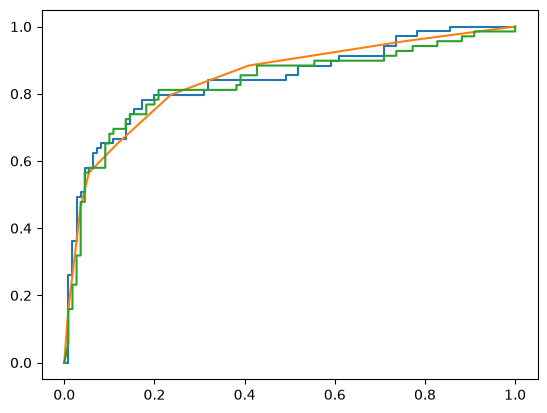

In [47]:
for model_name, model in models.items():
    pipeline = Pipeline(steps=[
                                ("preprocessor", preprocessor),
                                ("model", model)
    ])

    cv_scores = cross_val_score(pipeline,X_train, y_train, cv = cv, scoring="roc_auc", n_jobs= -1)

    results[model_name] = {"mean_cv_roc_auc": cv_scores.mean(), 
                           "std_cv_roc_auc": cv_scores.std()
                           }

    print(f"{model_name}")
    print(f"roc_auc_scores {cv_scores}")

    pipeline.fit(X_train, y_train)
    # Get the probability of the positive class (Survived = 1)
    y_prob = pipeline.predict_proba(X_test)[:,1]

    # Calculate the roc_auc_score (auc = area under curve)
    auc_score = roc_auc_score(y_test, y_prob)

    # Calculate the point for roc_curve
    fpr, tpr, threshold = roc_curve(y_test, y_prob)

    # Plotting the models roc_curve
    plt.plot(fpr, tpr, label = f"{model_name}(auc = {auc_score})")

plt.plot([0,1], ls = "--", label = "RandomForestClassifier auc = 0.50")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")

plt.show()

